# Receiver Operating Characteristic Curve

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.shape

(768, 9)

In [10]:
x = df.iloc[:,:8]
y = df.iloc[:,-1]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

### Logistic Regression

In [17]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
lr_prob = lr.predict_proba(x_test)[:,1]
# Column 0 shows the probability of the negative/first class, and column 1 shows the positive/second class
lr_fpr, lr_tpr, lr_threshold = roc_curve(y_test, lr_prob)
lr_auc = roc_auc_score(y_test, lr_prob)

### SVC

In [32]:
s = SVC(probability=True,kernel='rbf')
s.fit(x_train, y_train)
s_prob = s.predict_proba(x_test)[:, 1]
s_fpr, s_tpr, s_threshold = roc_curve(y_test, s_prob)
s_auc = roc_auc_score(y_test, s_prob)

## Plot

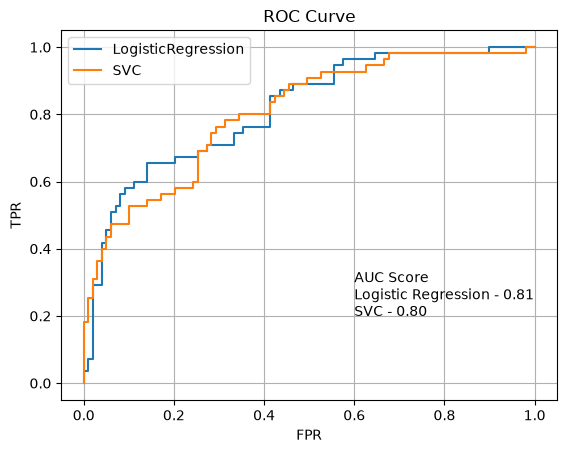

In [41]:
plt.plot(lr_fpr, lr_tpr, label='LogisticRegression')
plt.plot(s_fpr, s_tpr, label='SVC')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.title('ROC Curve')

plt.text(0.6, 0.2, f'AUC Score\nLogistic Regression - {lr_auc:.2f}\nSVC - {s_auc:.2f}')

plt.legend()
plt.grid()
plt.show()

## Optimum Threshold

In [42]:
# where TPR is highest and FPR is lowest
optimum_idx = np.argmax(lr_tpr - lr_fpr)
lr_threshold[optimum_idx]

np.float64(0.5398912042752616)